<a href="https://www.kaggle.com/code/farazkhanbsai/braintumourpreprocessing?scriptVersionId=329712997" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

<a href="https://www.kaggle.com/code/farazkhanbsai/braintumourpreprocessing?scriptVersionId=325618454" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# **Data Varification**

### Simple Brain Tumor Dataset Verification Script
### No MONAI required - uses only nibabel, numpy, matplotlib


In [1]:

import os
import sys
import json
import random
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from datetime import datetime
import pandas as pd



print("Imports complete")

Imports complete


In [2]:

# ============================ CONFIG ============================
# Change these paths to match your Kaggle/local setup
BASE_DIR = r"/kaggle/input/datasets/farazkhanbsai/braintumourdataset/BrainTumourDataset"
IMAGES_TR_DIR = os.path.join(BASE_DIR, "imagesTr")
LABELS_TR_DIR = os.path.join(BASE_DIR, "labelsTr")
IMAGES_TS_DIR = os.path.join(BASE_DIR, "imagesTs")
DATASET_JSON  = os.path.join(BASE_DIR, "dataset.json")

OUTPUT_DIR = "/kaggle/working"  # or "/mnt/agents/output" for local
RANDOM_SEED = 42
SAMPLES_TO_CHECK = 10  # how many random samples for dimension audit

os.makedirs(OUTPUT_DIR, exist_ok=True)
random.seed(RANDOM_SEED)

print("Config Complete")

Config Complete


In [3]:
# ============================ HELPERS ============================
def log_print(msg, log_file):
    print(msg)
    log_file.write(msg + "\\n")

def load_nifti_safe(filepath, log_file):
    """Load a NIfTI file and catch corruption."""
    try:
        img = nib.load(filepath)
        data = img.get_fdata()
        return data, img.header, img.affine
    except Exception as e:
        log_print(f"  [ERROR] Failed to load: {os.path.basename(filepath)} | {e}", log_file)
        return None, None, None


In [4]:

# ============================ MAIN ============================
def main():
    report_path = os.path.join(OUTPUT_DIR, "validation_report.txt")
    f = open(report_path, "w")
    
    log_print("=" * 60, f)
    log_print("DATASET VERIFICATION REPORT", f)
    log_print(f"Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}", f)
    log_print("=" * 60, f)
    
    # ---------- 1. FILE COUNT CHECK ----------
    log_print("\\n[STEP 1] File Count Check", f)
    
    if not os.path.exists(BASE_DIR):
        log_print(f"FATAL: Base directory not found: {BASE_DIR}", f)
        f.close()
        sys.exit(1)
    
    img_tr_files = sorted([x for x in os.listdir(IMAGES_TR_DIR) if x.endswith('.nii') or x.endswith('.nii.gz')])
    lbl_tr_files = sorted([x for x in os.listdir(LABELS_TR_DIR) if x.endswith('.nii') or x.endswith('.nii.gz')])
    img_ts_files = sorted([x for x in os.listdir(IMAGES_TS_DIR) if x.endswith('.nii') or x.endswith('.nii.gz')]) if os.path.exists(IMAGES_TS_DIR) else []
    
    log_print(f"  imagesTr : {len(img_tr_files)} files", f)
    log_print(f"  labelsTr : {len(lbl_tr_files)} files", f)
    log_print(f"  imagesTs : {len(img_ts_files)} files", f)
    
    if len(img_tr_files) != len(lbl_tr_files):
        log_print("  [WARNING] Mismatch in training image/label counts!", f)
    
    # ---------- 2. FILENAME MATCHING ----------
    log_print("\\n[STEP 2] Filename Matching", f)
    img_names = set([os.path.splitext(x)[0].replace('.nii', '') for x in img_tr_files])
    lbl_names = set([os.path.splitext(x)[0].replace('.nii', '') for x in lbl_tr_files])
    
    missing_labels = img_names - lbl_names
    missing_images = lbl_names - img_names
    
    if missing_labels:
        log_print(f"  [WARNING] Images without labels: {missing_labels}", f)
    if missing_images:
        log_print(f"  [WARNING] Labels without images: {missing_images}", f)
    if not missing_labels and not missing_images:
        log_print("  All training images have matching labels.", f)
    
    # ---------- 3. NIfTI INTEGRITY + DIMENSION AUDIT ----------
    log_print("\\n[STEP 3] NIfTI Integrity & Dimension Audit", f)
    log_print(f"  Checking {SAMPLES_TO_CHECK} random samples from imagesTr...", f)
    
    sample_pool = img_tr_files.copy()
    random.shuffle(sample_pool)
    checked_samples = sample_pool[:SAMPLES_TO_CHECK]
    
    dim_stats = []
    corrupted_files = []
    label_value_issues = []
    
    for fname in checked_samples:
        img_path = os.path.join(IMAGES_TR_DIR, fname)
        lbl_path = os.path.join(LABELS_TR_DIR, fname)
        
        # Check image
        img_data, img_hdr, img_aff = load_nifti_safe(img_path, f)
        if img_data is None:
            corrupted_files.append(fname)
            continue
        
        # Check label
        lbl_data, lbl_hdr, lbl_aff = load_nifti_safe(lbl_path, f)
        if lbl_data is None:
            corrupted_files.append(fname)
            continue
        
        img_shape = img_data.shape
        lbl_shape = lbl_data.shape
        
        log_print(f"  {fname}: Image={img_shape}, Label={lbl_shape}", f)
        dim_stats.append({"file": fname, "img_shape": img_shape, "lbl_shape": lbl_shape})
        
        # Verify 4D image, 3D label
        if len(img_shape) != 4:
            log_print(f"    [WARNING] Image is NOT 4D! Found {len(img_shape)}D", f)
        if len(lbl_shape) != 3:
            log_print(f"    [WARNING] Label is NOT 3D! Found {len(lbl_shape)}D", f)
    
    # ---------- 4. LABEL VALUE VERIFICATION (all 484 masks) ----------
    log_print("\\n[STEP 4] Label Value Verification (Full Scan)", f)
    log_print(f"  Scanning all {len(lbl_tr_files)} label files for unexpected values...", f)
    
    all_label_values = set()
    label_value_counts = {0:0, 1:0, 2:0, 3:0, "other":0}
    
    for i, fname in enumerate(lbl_tr_files):
        if i % 100 == 0:
            log_print(f"    Progress: {i}/{len(lbl_tr_files)}...", f)
        
        lbl_path = os.path.join(LABELS_TR_DIR, fname)
        lbl_data, _, _ = load_nifti_safe(lbl_path, f)
        if lbl_data is None:
            continue
        
        unique_vals = np.unique(lbl_data).astype(int)
        all_label_values.update(unique_vals.tolist())
        
        for v in unique_vals:
            if v in label_value_counts:
                label_value_counts[v] += 1
            else:
                label_value_counts["other"] += 1
                label_value_issues.append((fname, v))
    
    log_print(f"  Unique values found across all masks: {sorted(all_label_values)}", f)
    log_print(f"  Expected: {{0, 1, 2, 3}}", f)
    
    if label_value_issues:
        log_print(f"  [WARNING] Found {len(label_value_issues)} masks with unexpected values!", f)
        # Show first 10 issues
        for issue in label_value_issues[:10]:
            log_print(f"    {issue[0]} contains value {issue[1]}", f)
    else:
        log_print("  All labels contain only expected values {0, 1, 2, 3}.", f)
    
    # ---------- 5. MODALITY CHANNEL VERIFICATION ----------
    log_print("\\n[STEP 5] Modality Channel Verification", f)
    log_print("  Checking that 4 channels are not identical (corruption check)...", f)
    
    # Pick first valid sample from our checked samples
    test_sample = None
    for d in dim_stats:
        if len(d["img_shape"]) == 4 and d["img_shape"][-1] == 4:
            test_sample = d["file"]
            break
    
    if test_sample:
        img_path = os.path.join(IMAGES_TR_DIR, test_sample)
        img_data, _, _ = load_nifti_safe(img_path, f)
        
        channels_identical = True
        for i in range(4):
            for j in range(i+1, 4):
                if not np.allclose(img_data[..., i], img_data[..., j]):
                    channels_identical = False
                    break
        
        if channels_identical:
            log_print("  [WARNING] All 4 channels are identical! Possible data corruption.", f)
        else:
            log_print("  Channels are different. Data looks valid.", f)
        
        # Save preview figure
        fig, axes = plt.subplots(1, 4, figsize=(16, 4))
        slice_idx = img_data.shape[2] // 2  # middle slice
        
        modality_names = ["FLAIR", "T1", "T1ce", "T2"]
        for i in range(4):
            axes[i].imshow(img_data[:, :, slice_idx, i], cmap="gray")
            axes[i].set_title(f"{modality_names[i]} (ch {i})")
            axes[i].axis("off")
        
        plt.suptitle(f"Sample: {test_sample} | Slice {slice_idx}")
        plt.tight_layout()
        preview_path = os.path.join(OUTPUT_DIR, "sample_channel_preview.png")
        plt.savefig(preview_path, dpi=150, bbox_inches="tight")
        plt.close()
        log_print(f"  Saved channel preview to: {preview_path}", f)
    else:
        log_print("  [WARNING] No valid 4D sample found for channel verification.", f)
    
    # ---------- SUMMARY ----------
    log_print("\\n" + "=" * 60, f)
    log_print("SUMMARY", f)
    log_print("=" * 60, f)
    log_print(f"Total training pairs     : {len(img_tr_files)}", f)
    log_print(f"Corrupted files found    : {len(corrupted_files)}", f)
    log_print(f"Label value issues       : {len(label_value_issues)}", f)
    log_print(f"Unique label values      : {sorted(all_label_values)}", f)
    log_print(f"Dimension samples checked: {len(dim_stats)}", f)
    
    if dim_stats:
        shapes = [d["img_shape"] for d in dim_stats]
        log_print(f"Sample image shapes      : {shapes[:5]}", f)
    
    f.close()
    print(f"\\nDone! Report saved to: {report_path}")

In [5]:
if __name__ == "__main__":
    main()


DATASET VERIFICATION REPORT
Timestamp: 2026-06-23 08:14:03
\n[STEP 1] File Count Check
  imagesTr : 484 files
  labelsTr : 484 files
  imagesTs : 289 files
\n[STEP 2] Filename Matching
  All training images have matching labels.
\n[STEP 3] NIfTI Integrity & Dimension Audit
  Checking 10 random samples from imagesTr...
  BRATS_370.nii: Image=(240, 240, 155, 4), Label=(240, 240, 155)
  BRATS_157.nii: Image=(240, 240, 155, 4), Label=(240, 240, 155)
  BRATS_042.nii: Image=(240, 240, 155, 4), Label=(240, 240, 155)
  BRATS_046.nii: Image=(240, 240, 155, 4), Label=(240, 240, 155)
  BRATS_229.nii: Image=(240, 240, 155, 4), Label=(240, 240, 155)
  BRATS_095.nii: Image=(240, 240, 155, 4), Label=(240, 240, 155)
  BRATS_197.nii: Image=(240, 240, 155, 4), Label=(240, 240, 155)
  BRATS_171.nii: Image=(240, 240, 155, 4), Label=(240, 240, 155)
  BRATS_193.nii: Image=(240, 240, 155, 4), Label=(240, 240, 155)
  BRATS_130.nii: Image=(240, 240, 155, 4), Label=(240, 240, 155)
\n[STEP 4] Label Value Verific

# **Scan the Testing Folder**

In [6]:
# ============================ SCAN TESTING FOLDER ============================


IMAGES_TS_DIR = os.path.join(BASE_DIR, "imagesTs")

print("Scanning testing images folder for problematic files...")
print(f"Path: {IMAGES_TS_DIR}\n")

if not os.path.exists(IMAGES_TS_DIR):
    print("ERROR: imagesTs directory does not exist.")
else:
    all_ts_files = sorted(os.listdir(IMAGES_TS_DIR))
    print(f"Total entries found: {len(all_ts_files)}")

    # Identify problematic files
    problematic = []
    valid_nifti = []

    for fname in all_ts_files:
        full_path = os.path.join(IMAGES_TS_DIR, fname)
        # Check for hidden/macOS resource fork files (start with "._" or ".")
        if fname.startswith("._") or fname.startswith("."):
            problematic.append((fname, "Hidden/macOS metadata file"))
        elif not (fname.endswith('.nii') or fname.endswith('.nii.gz')):
            problematic.append((fname, "Not a NIfTI file extension"))
        elif os.path.getsize(full_path) == 0:
            problematic.append((fname, "Empty file (0 bytes)"))
        else:
            valid_nifti.append(fname)

    print(f"\nValid NIfTI files (.nii / .nii.gz): {len(valid_nifti)}")
    print(f"Problematic files: {len(problematic)}")

    if problematic:
        print("\n--- Problematic Files ---")
        for f, reason in problematic:
            print(f"  {f}  ({reason})")
    else:
        print("  No problematic files found. All clear!")

    # Optional: quick NIfTI integrity check on a few valid files
    if valid_nifti:
        print("\nQuick integrity check on 3 random valid files...")
        import random, nibabel as nib
        for fname in random.sample(valid_nifti, min(3, len(valid_nifti))):
            try:
                img = nib.load(os.path.join(IMAGES_TS_DIR, fname))
                print(f"  {fname}: shape={img.shape}, OK")
            except Exception as e:
                print(f"  {fname}: FAILED - {e}")

Scanning testing images folder for problematic files...
Path: /kaggle/input/datasets/farazkhanbsai/braintumourdataset/BrainTumourDataset/imagesTs

Total entries found: 289

Valid NIfTI files (.nii / .nii.gz): 266
Problematic files: 23

--- Problematic Files ---
  ._BRATS_487.nii.gz  (Hidden/macOS metadata file)
  ._BRATS_488.nii.gz  (Hidden/macOS metadata file)
  ._BRATS_490.nii.gz  (Hidden/macOS metadata file)
  ._BRATS_493.nii.gz  (Hidden/macOS metadata file)
  ._BRATS_494.nii.gz  (Hidden/macOS metadata file)
  ._BRATS_495.nii.gz  (Hidden/macOS metadata file)
  ._BRATS_501.nii.gz  (Hidden/macOS metadata file)
  ._BRATS_512.nii.gz  (Hidden/macOS metadata file)
  ._BRATS_514.nii.gz  (Hidden/macOS metadata file)
  ._BRATS_548.nii.gz  (Hidden/macOS metadata file)
  ._BRATS_610.nii.gz  (Hidden/macOS metadata file)
  ._BRATS_611.nii.gz  (Hidden/macOS metadata file)
  ._BRATS_661.nii.gz  (Hidden/macOS metadata file)
  ._BRATS_676.nii.gz  (Hidden/macOS metadata file)
  ._BRATS_680.nii.gz  (H

### **Create a clean_test_list.json of the path of file that are correct formated from the directory of imagesTs (testing data)**

In [7]:


TEST_DIR = r"/kaggle/input/datasets/farazkhanbsai/braintumourdataset/BrainTumourDataset/imagesTs"
OUTPUT_FILE = "/kaggle/working/clean_test_list.json"

# Get all filenames, filter out hidden/macOS metadata/empty files
all_files = os.listdir(TEST_DIR)
clean = []
for f in all_files:
    # Skip hidden files, macOS resource forks (._) and anything not .nii or .nii.gz
    if f.startswith("._") or f.startswith("."):
        continue
    if not (f.endswith(".nii") or f.endswith(".nii.gz")):
        continue
    full_path = os.path.join(TEST_DIR, f)
    if os.path.getsize(full_path) == 0:
        continue
    clean.append(full_path)

clean = sorted(clean)

# Save the clean list
with open(OUTPUT_FILE, "w") as f:
    json.dump(clean, f, indent=2)

print(f"Clean test images: {len(clean)}")
print(f"List saved to {OUTPUT_FILE}")
print(f"First 3 files: {clean[:3]}")

Clean test images: 266
List saved to /kaggle/working/clean_test_list.json
First 3 files: ['/kaggle/input/datasets/farazkhanbsai/braintumourdataset/BrainTumourDataset/imagesTs/BRATS_485.nii', '/kaggle/input/datasets/farazkhanbsai/braintumourdataset/BrainTumourDataset/imagesTs/BRATS_486.nii', '/kaggle/input/datasets/farazkhanbsai/braintumourdataset/BrainTumourDataset/imagesTs/BRATS_487.nii']


# Note
* We cannot remove or delete file from Input section and our test data contian 23 Problematic files.
* so for solving that problem we create the (/kaggle/working/clean_test_list.json)  and put the paths if the .nii files that are non-problematic.
* if we copy the test folder correct files it will exceed our Storage limit


# EDA  

## Build Clean File Lists (Training Pairs + Test)

In [8]:


BASE = r"/kaggle/input/datasets/farazkhanbsai/braintumourdataset/BrainTumourDataset"
TR_IMG = os.path.join(BASE, "imagesTr")
TR_LBL = os.path.join(BASE, "labelsTr")
TS_IMG = os.path.join(BASE, "imagesTs")

def get_valid(folder):
    """Return sorted list of .nii/.nii.gz files, skipping hidden/._ empty."""
    if not os.path.exists(folder): return []
    return sorted([
        f for f in os.listdir(folder)
        if not f.startswith("._") and not f.startswith(".")
        and (f.endswith(".nii") or f.endswith(".nii.gz"))
        and os.path.getsize(os.path.join(folder, f)) > 0
    ])

tr_img_files = get_valid(TR_IMG)
tr_lbl_files = get_valid(TR_LBL)
ts_files = get_valid(TS_IMG)

print(f"Clean training images : {len(tr_img_files)}")
print(f"Clean training labels : {len(tr_lbl_files)}")
print(f"Clean test images     : {len(ts_files)}")

# Match image-label pairs by base name (remove .nii/.nii.gz)
img_bases = {os.path.splitext(f)[0].replace(".nii","") for f in tr_img_files}
lbl_bases = {os.path.splitext(f)[0].replace(".nii","") for f in tr_lbl_files}
matched = sorted(img_bases & lbl_bases)

pairs = []
for name in matched:
    # find the actual filename (handles .nii or .nii.gz)
    img_f = next(f for f in tr_img_files if f.startswith(name))
    lbl_f = next(f for f in tr_lbl_files if f.startswith(name))
    pairs.append({
        "image": os.path.join(TR_IMG, img_f),
        "label": os.path.join(TR_LBL, lbl_f)
    })

# Test list
test_list = [os.path.join(TS_IMG, f) for f in ts_files]

with open("/kaggle/working/train_pairs.json", "w") as f:
    json.dump(pairs, f, indent=2)
with open("/kaggle/working/test_images.json", "w") as f:
    json.dump(test_list, f, indent=2)

print(f"Saved train_pairs.json ({len(pairs)} pairs) and test_images.json ({len(test_list)} files)")

Clean training images : 484
Clean training labels : 484
Clean test images     : 266
Saved train_pairs.json (484 pairs) and test_images.json (266 files)


##  Voxel Spacing Analysis

Spacing stats (mm) – x, y, z:
  axis 0: min=1.000, max=1.000, mean=1.000, std=0.000
  axis 1: min=1.000, max=1.000, mean=1.000, std=0.000
  axis 2: min=1.000, max=1.000, mean=1.000, std=0.000


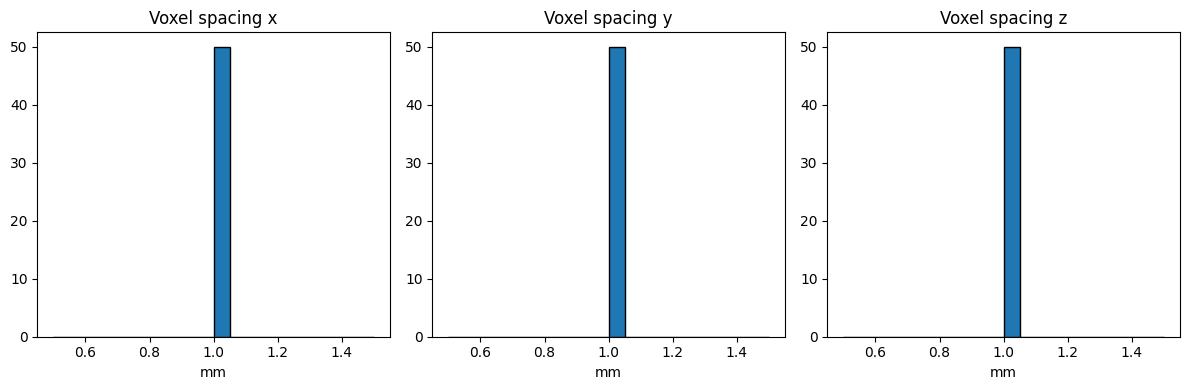

Saved eda_spacing.png and spacing_sample.csv


In [9]:


random.seed(42)
with open("/kaggle/working/train_pairs.json") as f:
    pairs = json.load(f)

sample = random.sample(pairs, min(50, len(pairs)))
spacings = []
for p in sample:
    aff = nib.load(p["image"]).affine
    spacing = np.sqrt((aff[:3, :3] ** 2).sum(axis=0))
    spacings.append(spacing)

spacings = np.array(spacings)  # shape (N, 3)
print("Spacing stats (mm) – x, y, z:")
for ax in range(3):
    print(f"  axis {ax}: min={spacings[:,ax].min():.3f}, max={spacings[:,ax].max():.3f}, mean={spacings[:,ax].mean():.3f}, std={spacings[:,ax].std():.3f}")

# Save CSV
np.savetxt("/kaggle/working/spacing_sample.csv", spacings, header="spacing_x,spacing_y,spacing_z", delimiter=",", comments="")

# Histogram
fig, axes = plt.subplots(1,3, figsize=(12,4))
for i, ax_name in enumerate(["x", "y", "z"]):
    axes[i].hist(spacings[:,i], bins=20, edgecolor="k")
    axes[i].set_title(f"Voxel spacing {ax_name}")
    axes[i].set_xlabel("mm")
plt.tight_layout()
plt.savefig("/kaggle/working/eda_spacing.png", dpi=150)
plt.show()
print("Saved eda_spacing.png and spacing_sample.csv")

## Spatial Dimension Distribution

Found 484 images
Dimension stats (H, W, D):
  H: min=240, max=240, unique=[240]
  W: min=240, max=240, unique=[240]
  D: min=155, max=155, unique=[155]


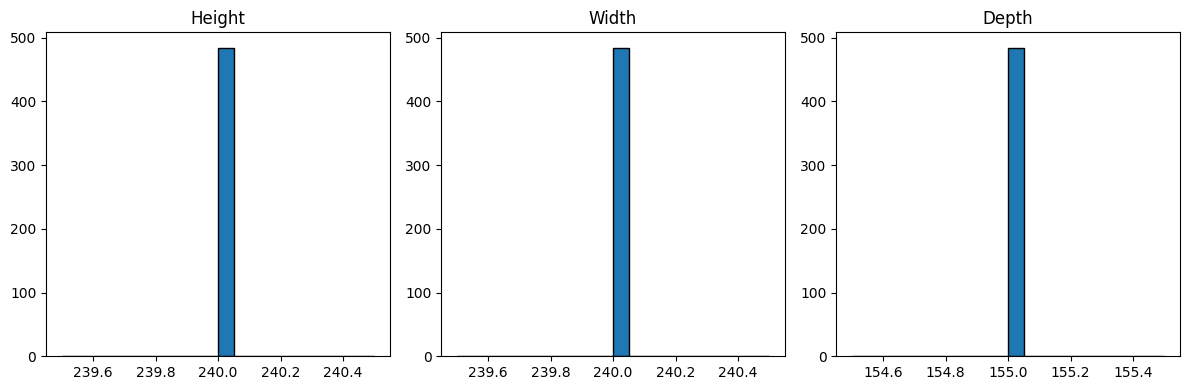

Saved dimensions.csv and eda_dimensions.png


In [10]:


with open("/kaggle/working/train_pairs.json") as f:
    pairs = json.load(f)

dims = []
for p in pairs:
    shape = nib.load(p["image"]).shape
    dims.append(shape[:3])  # only spatial, ignore channels

dims = np.array(dims)
print(f"Found {dims.shape[0]} images")
print("Dimension stats (H, W, D):")
for i, ax in enumerate(["H", "W", "D"]):
    print(f"  {ax}: min={dims[:,i].min()}, max={dims[:,i].max()}, unique={np.unique(dims[:,i])}")

# Save CSV
np.savetxt("/kaggle/working/dimensions.csv", dims, header="H,W,D", delimiter=",", comments="", fmt='%d')

# Histogram
fig, axes = plt.subplots(1,3, figsize=(12,4))
for i, ax in enumerate(["Height", "Width", "Depth"]):
    axes[i].hist(dims[:,i], bins=20, edgecolor="k")
    axes[i].set_title(ax)
plt.tight_layout()
plt.savefig("/kaggle/working/eda_dimensions.png", dpi=150)
plt.show()
print("Saved dimensions.csv and eda_dimensions.png")

## Class Frequency & Tumor Volume

Class voxel counts: {0: np.int64(4271154985), 1: np.int64(31456687), 2: np.int64(8731567), 3: np.int64(9808761)}
Class imbalance ratio: bg=0.988, edema=0.007, non-enh=0.002, enh=0.002
Class weights: {'0': 0.0002355414603098426, '1': 0.031981565076340174, '2': 0.1152180453264075, '3': 0.10256484813694247}


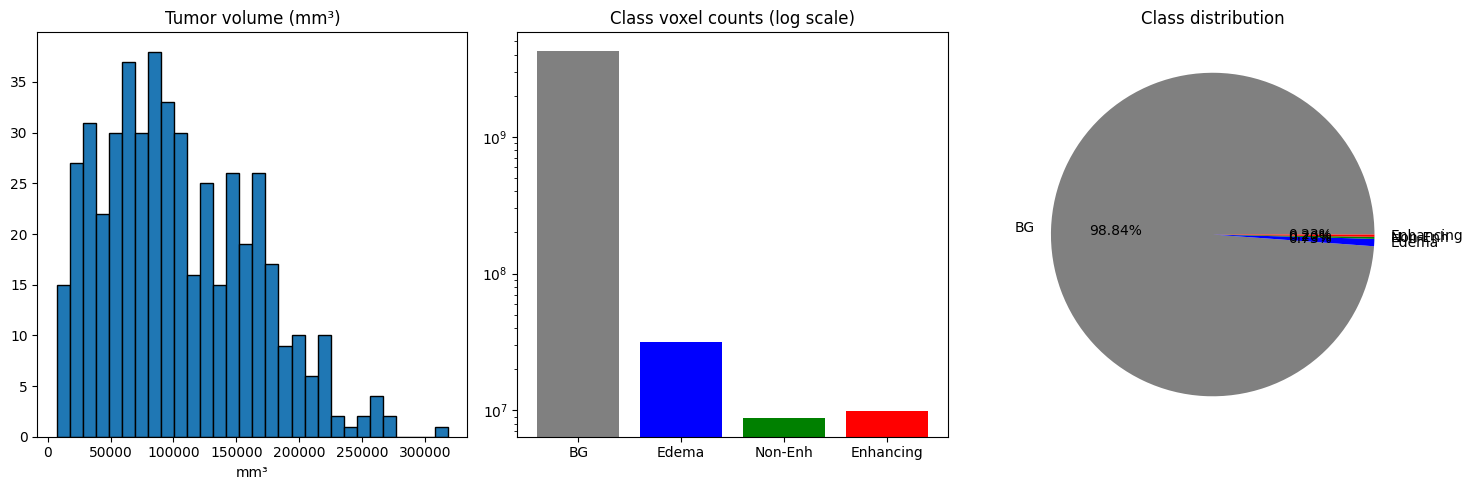

Saved class_weights.json, per_patient_stats.csv, eda_class_frequency.png


In [11]:

with open("/kaggle/working/train_pairs.json") as f:
    pairs = json.load(f)

class_counts = {0: [], 1: [], 2: [], 3: []}
tumor_volumes = []

for p in pairs:
    lbl = nib.load(p["label"]).get_fdata()
    # Voxel spacing from label header (assume it matches image)
    aff = nib.load(p["label"]).affine
    voxel_vol = np.abs(np.linalg.det(aff[:3,:3]))  # mm³ per voxel
    unique, counts = np.unique(lbl.astype(np.int8), return_counts=True)
    counts_dict = dict(zip(unique, counts))
    for c in [0,1,2,3]:
        class_counts[c].append(counts_dict.get(c, 0))
    tumor_vol = (counts_dict.get(1,0) + counts_dict.get(2,0) + counts_dict.get(3,0)) * voxel_vol
    tumor_volumes.append(tumor_vol)

# Convert to arrays
total_voxels = np.array([sum(class_counts[i]) for i in range(4)])
frequencies = {c: np.sum(class_counts[c]) for c in range(4)}
print("Class voxel counts:", frequencies)
print(f"Class imbalance ratio: bg={frequencies[0]/total_voxels.sum():.3f}, edema={frequencies[1]/total_voxels.sum():.3f}, non-enh={frequencies[2]/total_voxels.sum():.3f}, enh={frequencies[3]/total_voxels.sum():.3f}")

# Class weights: inverse frequency, normalized
weights = 1.0 / np.array([frequencies[c] for c in range(4)])
weights /= weights.sum() * 4  # scaled so average weight = 1
class_weights_dict = {str(c): float(weights[c]) for c in range(4)}
with open("/kaggle/working/class_weights.json", "w") as f:
    json.dump(class_weights_dict, f, indent=2)
print("Class weights:", class_weights_dict)

# Per-patient stats DataFrame
df = pd.DataFrame({
    "bg": class_counts[0],
    "edema": class_counts[1],
    "non_enhancing": class_counts[2],
    "enhancing": class_counts[3],
    "tumor_volume_mm3": tumor_volumes
})
df.to_csv("/kaggle/working/per_patient_stats.csv", index=False)

# Plots
fig, axes = plt.subplots(1,3, figsize=(15,5))

# Total tumor volume histogram
axes[0].hist(tumor_volumes, bins=30, edgecolor="k")
axes[0].set_title("Tumor volume (mm³)")
axes[0].set_xlabel("mm³")

# Per-class voxel counts (log scale bar)
classes = ["BG", "Edema", "Non-Enh", "Enhancing"]
counts = [frequencies[c] for c in range(4)]
axes[1].bar(classes, counts, log=True, color=['gray','blue','green','red'])
axes[1].set_title("Class voxel counts (log scale)")

# Pie chart for class imbalance
axes[2].pie([frequencies[c] for c in range(4)], labels=classes, autopct='%1.2f%%', colors=['gray','blue','green','red'])
axes[2].set_title("Class distribution")
plt.tight_layout()
plt.savefig("/kaggle/working/eda_class_frequency.png", dpi=150)
plt.show()
print("Saved class_weights.json, per_patient_stats.csv, eda_class_frequency.png")

## Intensity Distribution per Modality

### This Code ******************

Loading 20 volumes in parallel...


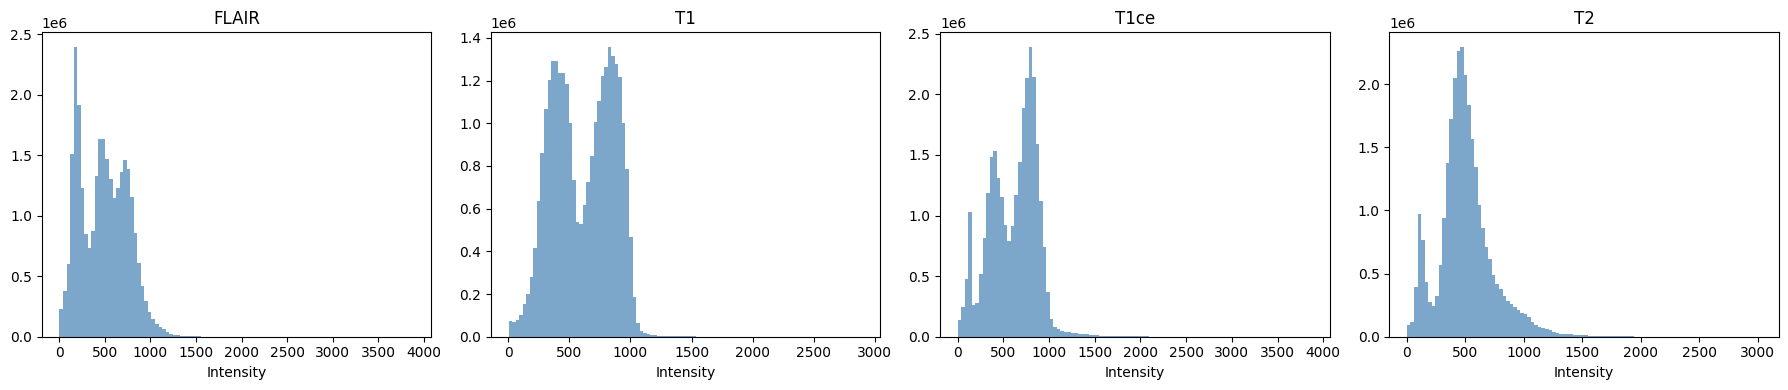

       min     max        mean         std
FLAIR  1.0  3888.0  486.308387  258.874364
T1     1.0  2903.0  608.336334  246.548096
T1ce   1.0  3875.0  610.955318  259.427340
T2     1.0  3027.0  503.031261  236.039101
Saved eda_intensity.png and intensity_stats.csv


In [12]:

from concurrent.futures import ThreadPoolExecutor

# Load file list
with open("/kaggle/working/train_pairs.json") as f:
    pairs = json.load(f)
random.seed(42)
sample = random.sample(pairs, min(20, len(pairs)))

def extract_intensities(file_path):
    """Return four lists of non-zero voxel intensities for each channel."""
    img = nib.load(file_path).get_fdata()
    results = []
    for ch in range(4):
        data = img[..., ch]
        vals = data[data > 0].ravel().tolist()  # skip background
        results.append(vals)
    return results

# Parallel loading
print(f"Loading {len(sample)} volumes in parallel...")
with ThreadPoolExecutor(max_workers=4) as executor:   # adjust workers based on CPU
    all_results = list(executor.map(extract_intensities, [p["image"] for p in sample]))

# Combine per-channel
intensities = {i: [] for i in range(4)}
for res in all_results:
    for ch in range(4):
        intensities[ch].extend(res[ch])

# Plot
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
mod_names = ["FLAIR", "T1", "T1ce", "T2"]
for ch in range(4):
    axes[ch].hist(intensities[ch], bins=100, color='steelblue', edgecolor='none', alpha=0.7)
    axes[ch].set_title(mod_names[ch])
    axes[ch].set_xlabel("Intensity")
plt.tight_layout()
plt.savefig("/kaggle/working/eda_intensity.png", dpi=150)
plt.show()

# Statistics
stats = {}
for ch in range(4):
    arr = np.array(intensities[ch])
    stats[mod_names[ch]] = {
        "min": float(arr.min()), "max": float(arr.max()),
        "mean": float(arr.mean()), "std": float(arr.std())
    }
stats_df = pd.DataFrame(stats).T
stats_df.to_csv("/kaggle/working/intensity_stats.csv")
print(stats_df)
print("Saved eda_intensity.png and intensity_stats.csv")

## Foreground Bounding Box Analysis

## THis code **********************


Processing 484 label masks in parallel...
Mean crop ratio per axis: [0.7299759  0.63499483 0.54709411]
Typical brain region size: [64 87 70]
Typical image size: [240 240 155]


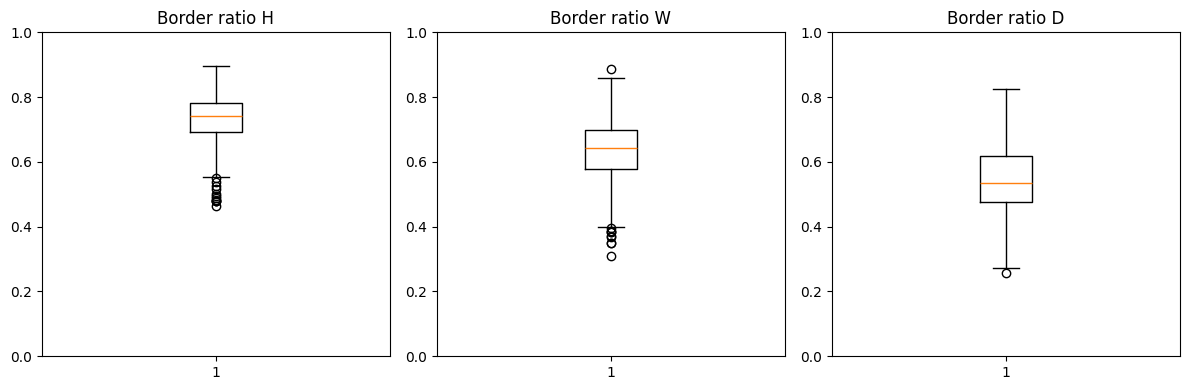

Saved foreground_bbox.csv and eda_bbox.png


In [13]:


with open("/kaggle/working/train_pairs.json") as f:
    pairs = json.load(f)

def get_bbox_sizes(label_path):
    """Return (full_shape, bbox_shape) for one mask."""
    lbl = nib.load(label_path).get_fdata()
    full_shape = lbl.shape
    fg = lbl > 0
    if not fg.any():
        return None
    coords = np.argwhere(fg)
    min_c = coords.min(axis=0)
    max_c = coords.max(axis=0)
    bbox_shape = max_c - min_c + 1
    return (full_shape, bbox_shape)

print(f"Processing {len(pairs)} label masks in parallel...")
with ThreadPoolExecutor(max_workers=4) as executor:
    results = list(executor.map(get_bbox_sizes, [p["label"] for p in pairs]))

# Filter out None (empty masks – shouldn't happen)
results = [r for r in results if r is not None]
full_sizes, bbox_sizes = zip(*results)
full_sizes = np.array(full_sizes)
bbox_sizes = np.array(bbox_sizes)
crop_ratios = 1.0 - (bbox_sizes / full_sizes)

print("Mean crop ratio per axis:", crop_ratios.mean(axis=0))
print("Typical brain region size:", bbox_sizes.mean(axis=0).astype(int))
print("Typical image size:", full_sizes.mean(axis=0).astype(int))

# Save
df = pd.DataFrame({
    "full_H": full_sizes[:,0], "full_W": full_sizes[:,1], "full_D": full_sizes[:,2],
    "bbox_H": bbox_sizes[:,0], "bbox_W": bbox_sizes[:,1], "bbox_D": bbox_sizes[:,2]
})
df.to_csv("/kaggle/working/foreground_bbox.csv", index=False)

# Boxplot
fig, axes = plt.subplots(1,3, figsize=(12,4))
for i, ax in enumerate(["H", "W", "D"]):
    axes[i].boxplot(crop_ratios[:,i])
    axes[i].set_title(f"Border ratio {ax}")
    axes[i].set_ylim(0,1)
plt.tight_layout()
plt.savefig("/kaggle/working/eda_bbox.png", dpi=150)
plt.show()
print("Saved foreground_bbox.csv and eda_bbox.png")

### **________________________  EDA Completed ____________________________**

# **PreProcessing**

##  **Install & Import Dependencies**

In [14]:
# Cell 1: Imports and reproducibility setup
import json
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import nibabel as nib
import matplotlib.pyplot as plt
import os
import random
from tqdm import tqdm

# Set random seeds for reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

print("Setup complete (MONAI not required).")

Setup complete (MONAI not required).


## **Helper Functions (Orientation, Cropping, Padding, Normalization)**

In [15]:
# Cell 2: All preprocessing helpers (fixed padding for 4D labels)

PATCH_SIZE = (128, 128, 128)          # output patch size
TARGET_ORIENTATION = "RAS"            # we will enforce RAS using nibabel
MIN_SIZE = 128                        # minimum dimension after cropping
CROP_FOREGROUND = True

# ----- Orientation helper (RAS) -----
def to_ras(image_nib, label_nib=None):
    """Reorient image and label (if given) to RAS+ using nibabel's as_closest_canonical."""
    img_ras = nib.as_closest_canonical(image_nib)
    if label_nib is not None:
        lbl_ras = nib.as_closest_canonical(label_nib)
        return img_ras, lbl_ras
    return img_ras, None

# ----- Foreground bounding box (based on label) -----
def get_foreground_bbox(label_data):
    """Return (min_x, max_x, min_y, max_y, min_z, max_z) for non-zero label voxels."""
    coords = np.argwhere(label_data > 0)
    if len(coords) == 0:
        # No foreground → full volume
        return (0, label_data.shape[0], 0, label_data.shape[1], 0, label_data.shape[2])
    min_x, max_x = coords[:, 0].min(), coords[:, 0].max() + 1
    min_y, max_y = coords[:, 1].min(), coords[:, 1].max() + 1
    min_z, max_z = coords[:, 2].min(), coords[:, 2].max() + 1
    return min_x, max_x, min_y, max_y, min_z, max_z

def apply_foreground_crop(image_data, label_data):
    """
    Crop image (C,H,W,D) and label (H,W,D) to label bounding box.
    Label is assumed to be 3D (no channel dimension).
    """
    bbox = get_foreground_bbox(label_data)
    min_x, max_x, min_y, max_y, min_z, max_z = bbox
    img_cropped = image_data[:, min_x:max_x, min_y:max_y, min_z:max_z]
    lbl_cropped = label_data[min_x:max_x, min_y:max_y, min_z:max_z]
    return img_cropped, lbl_cropped

# ----- Padding to minimum size (supports both 3D and 4D label) -----
def pad_to_min_size(image_data, label_data, min_size=MIN_SIZE):
    """
    Pad image (C,H,W,D) and label (C,H,W,D) or (H,W,D) to at least min_size per dimension.
    Returns padded image and label with same dimensionality as input.
    """
    _, h, w, d = image_data.shape
    pad_h = max(0, min_size - h)
    pad_w = max(0, min_size - w)
    pad_d = max(0, min_size - d)
    
    # Symmetric padding
    pad_h_left = pad_h // 2
    pad_h_right = pad_h - pad_h_left
    pad_w_left = pad_w // 2
    pad_w_right = pad_w - pad_w_left
    pad_d_left = pad_d // 2
    pad_d_right = pad_d - pad_d_left
    
    # Pad image (4D)
    img_padded = np.pad(image_data, ((0,0), (pad_h_left, pad_h_right), 
                                     (pad_w_left, pad_w_right), (pad_d_left, pad_d_right)),
                        mode='constant', constant_values=0)
    
    # Pad label – handle both 3D and 4D
    if label_data.ndim == 4:
        # Label has channel dimension (e.g., 1, H, W, D)
        lbl_padded = np.pad(label_data, ((0,0), (pad_h_left, pad_h_right),
                                         (pad_w_left, pad_w_right), (pad_d_left, pad_d_right)),
                            mode='constant', constant_values=0)
    else:
        # Label is 3D (H, W, D)
        lbl_padded = np.pad(label_data, ((pad_h_left, pad_h_right),
                                         (pad_w_left, pad_w_right),
                                         (pad_d_left, pad_d_right)),
                            mode='constant', constant_values=0)
    return img_padded, lbl_padded

# ----- Per‑channel normalization (z‑score over non‑zero voxels) -----
def normalize_channels(img_data):
    """Normalize each channel (C) using mean/std of non‑zero voxels only."""
    for c in range(img_data.shape[0]):
        channel = img_data[c]
        nonzero = channel[channel > 0]
        if len(nonzero) > 0:
            mean = nonzero.mean()
            std = nonzero.std()
            if std > 1e-8:
                img_data[c] = (channel - mean) / std
            else:
                img_data[c] = channel - mean
    return img_data

# ----- Spatial cropping (random for training, central for validation) -----
def random_crop_to_patch(image_data, label_data, patch_size):
    """Randomly crop both image (C,H,W,D) and label (C,H,W,D) to patch_size."""
    _, h, w, d = image_data.shape
    ph, pw, pd = patch_size
    if h < ph or w < pw or d < pd:
        raise ValueError(f"Volume {image_data.shape} smaller than patch {patch_size}")
    x = np.random.randint(0, h - ph + 1)
    y = np.random.randint(0, w - pw + 1)
    z = np.random.randint(0, d - pd + 1)
    img_crop = image_data[:, x:x+ph, y:y+pw, z:z+pd]
    lbl_crop = label_data[:, x:x+ph, y:y+pw, z:z+pd]   # label is 4D (C, H, W, D)
    return img_crop, lbl_crop

def central_crop_to_patch(image_data, label_data, patch_size):
    """Central crop both image (C,H,W,D) and label (C,H,W,D) to patch_size."""
    _, h, w, d = image_data.shape
    ph, pw, pd = patch_size
    x = (h - ph) // 2
    y = (w - pw) // 2
    z = (d - pd) // 2
    img_crop = image_data[:, x:x+ph, y:y+pw, z:z+pd]
    lbl_crop = label_data[:, x:x+ph, y:y+pw, z:z+pd]
    return img_crop, lbl_crop

# ----- Training‑only augmentations (geometric + intensity) -----
def apply_augmentations(image_data, label_data):
    """Random 90° rotations, flips, Gaussian noise, contrast adjustment."""
    # Geometric (same for image and label) – both are 4D (C, H, W, D)
    if np.random.rand() < 0.5:
        # Random 90° rotation around axial plane (axes 1,2 for H,W)
        k = np.random.randint(0, 4)
        image_data = np.rot90(image_data, k, axes=(1,2))
        label_data = np.rot90(label_data, k, axes=(1,2))
    if np.random.rand() < 0.5:
        # Random left‑right flip (axis 2? careful: after rotation, axes may shift)
        # We'll flip along width (axis=2)
        image_data = np.flip(image_data, axis=2).copy()
        label_data = np.flip(label_data, axis=2).copy()
    if np.random.rand() < 0.5:
        # Random anterior‑posterior flip (axis=1 for height)
        image_data = np.flip(image_data, axis=1).copy()
        label_data = np.flip(label_data, axis=1).copy()
    
    # Intensity augmentations (image only)
    if np.random.rand() < 0.2:
        noise = np.random.normal(0, 0.01, image_data.shape)
        image_data = image_data + noise.astype(np.float32)
    if np.random.rand() < 0.3:
        gamma = np.random.uniform(0.8, 1.2)
        image_data = np.power(np.clip(image_data, 0, None), gamma)
        image_data = np.clip(image_data, -5, 5)
    return image_data, label_data

print("All helper functions defined (padding fixed).")

All helper functions defined (padding fixed).


## **Main Preprocessing Function**

In [16]:
# Cell 3 (corrected) – Preprocessing function with negative stride fix
def preprocess_sample(image_path, label_path=None, augment=False, patch_size=PATCH_SIZE):
    """
    Returns:
        image_tensor: torch.FloatTensor of shape (4, patch_h, patch_w, patch_d)
        label_tensor: torch.LongTensor of shape (1, patch_h, patch_w, patch_d) or None
    """
    # 1. Load NIfTI
    img_nib = nib.load(image_path)
    img_data = img_nib.get_fdata().astype(np.float32)   # (H, W, D, 4)
    # 2. Channel‑first transpose
    img_data = np.transpose(img_data, (3, 0, 1, 2))     # (4, H, W, D)
    
    lbl_data = None
    if label_path is not None:
        lbl_nib = nib.load(label_path)
        lbl_data = lbl_nib.get_fdata().astype(np.int64) # (H, W, D)
        lbl_data = np.expand_dims(lbl_data, axis=0)     # (1, H, W, D)
    
    # 4. Orientation to RAS (using nibabel's as_closest_canonical)
    img_nib_ras = nib.Nifti1Image(img_data, img_nib.affine)
    if lbl_data is not None:
        lbl_float32 = lbl_data.astype(np.float32)
        lbl_nib_ras = nib.Nifti1Image(lbl_float32, lbl_nib.affine)
    else:
        lbl_nib_ras = None
    
    img_nib_ras, lbl_nib_ras = to_ras(img_nib_ras, lbl_nib_ras)
    img_data = img_nib_ras.get_fdata().astype(np.float32)
    if lbl_data is not None:
        lbl_data = lbl_nib_ras.get_fdata().astype(np.int64)
    
    # 6. Per‑channel intensity normalization (non‑zero only)
    img_data = normalize_channels(img_data)
    
    # 7. Foreground cropping
    if CROP_FOREGROUND and lbl_data is not None:
        lbl_3d = lbl_data[0, ...]
        img_data, lbl_3d = apply_foreground_crop(img_data, lbl_3d)
        lbl_data = np.expand_dims(lbl_3d, axis=0)
    
    # 8. Pad to minimum size
    if lbl_data is not None:
        img_data, lbl_data = pad_to_min_size(img_data, lbl_data, MIN_SIZE)
    else:
        dummy_label = np.zeros(img_data.shape[1:], dtype=np.int64)
        dummy_label = np.expand_dims(dummy_label, axis=0)
        img_data, _ = pad_to_min_size(img_data, dummy_label, MIN_SIZE)
    
    # 9. Spatial cropping to patch_size
    if lbl_data is not None:
        if augment:
            img_data, lbl_data = random_crop_to_patch(img_data, lbl_data, patch_size)
        else:
            img_data, lbl_data = central_crop_to_patch(img_data, lbl_data, patch_size)
    else:
        dummy_label = np.zeros((1, *img_data.shape[1:]), dtype=np.int64)
        if augment:
            img_data, _ = random_crop_to_patch(img_data, dummy_label, patch_size)
        else:
            img_data, _ = central_crop_to_patch(img_data, dummy_label, patch_size)
        lbl_data = None
    
    # 10. Training‑only augmentations
    if augment and lbl_data is not None:
        img_data, lbl_data = apply_augmentations(img_data, lbl_data)
    
    # 11. Convert to torch tensors – FIX: ensure contiguous arrays
    image_tensor = torch.from_numpy(np.ascontiguousarray(img_data)).float()
    if lbl_data is not None:
        label_tensor = torch.from_numpy(np.ascontiguousarray(lbl_data)).long()
    else:
        label_tensor = None
    
    return image_tensor, label_tensor

print("Preprocessing function redefined with negative stride fix.")

Preprocessing function redefined with negative stride fix.


## **PyTorch Dataset Classes**

In [17]:
# Cell 4: Dataset classes for training and inference

class BraTSDataset(Dataset):
    def __init__(self, pairs_list, augment=True):
        self.pairs = pairs_list
        self.augment = augment
    
    def __len__(self):
        return len(self.pairs)
    
    def __getitem__(self, idx):
        pair = self.pairs[idx]
        image, label = preprocess_sample(pair["image"], pair["label"], augment=self.augment)
        return image, label

class BraTSInferenceDataset(Dataset):
    def __init__(self, image_list):
        self.images = image_list
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        image_path = self.images[idx]
        image, _ = preprocess_sample(image_path, label_path=None, augment=False)
        return image, image_path

print("Dataset classes defined.")

Dataset classes defined.


## **Load File Lists & Create DataLoaders**

In [18]:
# Cell 5: Load the cleaned file lists

with open("train_pairs.json", "r") as f:
    train_pairs = json.load(f)

with open("clean_test_list.json", "r") as f:
    test_images = json.load(f)

print(f"Training pairs: {len(train_pairs)}")
print(f"Test images: {len(test_images)}")

# DataLoader settings
BATCH_SIZE = 4
NUM_WORKERS = 2

train_dataset = BraTSDataset(train_pairs, augment=True)
val_dataset = BraTSDataset(train_pairs, augment=False)   # same pairs for quick test
test_dataset = BraTSInferenceDataset(test_images)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=NUM_WORKERS)

print("DataLoaders ready.")

Training pairs: 484
Test images: 266
DataLoaders ready.


## **Verify Output Shapes**

In [19]:
# Cell 6: Quick test on one training sample

sample_img, sample_lbl = train_dataset[0]
print("Training sample:")
print(f"  Image shape: {sample_img.shape}  (expected (4,128,128,128))")
print(f"  Label shape: {sample_lbl.shape}  (expected (1,128,128,128))")
print(f"  Image dtype: {sample_img.dtype}, min={sample_img.min():.2f}, max={sample_img.max():.2f}")
print(f"  Label unique values: {torch.unique(sample_lbl).tolist()}")

# Validation sample (no augmentation)
val_img, val_lbl = val_dataset[0]
print("\nValidation sample (central crop):")
print(f"  Image shape: {val_img.shape}")
print(f"  Label shape: {val_lbl.shape}")

# Inference sample
test_img, test_path = test_dataset[0]
print("\nTest sample:")
print(f"  Image shape: {test_img.shape}")
print(f"  Path: {test_path}")

print("\nAll tests passed – preprocessing works without MONAI.")

Training sample:
  Image shape: torch.Size([4, 128, 128, 128])  (expected (4,128,128,128))
  Label shape: torch.Size([1, 128, 128, 128])  (expected (1,128,128,128))
  Image dtype: torch.float32, min=-3.78, max=6.65
  Label unique values: [0, 1, 2, 3]

Validation sample (central crop):
  Image shape: torch.Size([4, 128, 128, 128])
  Label shape: torch.Size([1, 128, 128, 128])

Test sample:
  Image shape: torch.Size([4, 128, 128, 128])
  Path: /kaggle/input/datasets/farazkhanbsai/braintumourdataset/BrainTumourDataset/imagesTs/BRATS_485.nii

All tests passed – preprocessing works without MONAI.


## **Save Preprocessing Parameters for Phase B**

In [20]:
# Cell 7: Export configuration to JSON

params = {
    "target_spacing_mm": [1.0, 1.0, 1.0],
    "patch_size": list(PATCH_SIZE),
    "orientation": TARGET_ORIENTATION,
    "normalization": "channelwise_zscore_nonzero",
    "foreground_cropping": CROP_FOREGROUND,
    "padding_mode": "constant",
    "padding_min_size": MIN_SIZE,
    "augmentations": {
        "random_rot90_prob": 0.5,
        "random_flip_prob": 0.5,
        "gaussian_noise_prob": 0.2,
        "contrast_adjustment_prob": 0.3,
        "random_seed": 42
    },
    "random_seeds": {
        "python": 42,
        "numpy": 42,
        "torch": 42
    }
}

with open("preprocessing_params.json", "w") as f:
    json.dump(params, f, indent=4)

print("Saved preprocessing parameters to preprocessing_params.json")
!cat preprocessing_params.json

Saved preprocessing parameters to preprocessing_params.json
{
    "target_spacing_mm": [
        1.0,
        1.0,
        1.0
    ],
    "patch_size": [
        128,
        128,
        128
    ],
    "orientation": "RAS",
    "normalization": "channelwise_zscore_nonzero",
    "foreground_cropping": true,
    "padding_mode": "constant",
    "padding_min_size": 128,
    "augmentations": {
        "random_rot90_prob": 0.5,
        "random_flip_prob": 0.5,
        "gaussian_noise_prob": 0.2,
        "contrast_adjustment_prob": 0.3,
        "random_seed": 42
    },
    "random_seeds": {
        "python": 42,
        "numpy": 42,
        "torch": 42
    }
}

-----------

---

# **Model Section**